<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Описание-проекта" data-toc-modified-id="Описание-проекта-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Описание проекта</a></span></li><li><span><a href="#Описание-данных" data-toc-modified-id="Описание-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Описание данных</a></span></li><li><span><a href="#Загрузка-и-подготовка-данных" data-toc-modified-id="Загрузка-и-подготовка-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Загрузка и подготовка данных</a></span><ul class="toc-item"><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Обучение-и-проверка-модели" data-toc-modified-id="Обучение-и-проверка-модели-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Обучение и проверка модели</a></span><ul class="toc-item"><li><span><a href="#Обучение-модели-для-региона-№0" data-toc-modified-id="Обучение-модели-для-региона-№0-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Обучение модели для региона №0</a></span></li><li><span><a href="#Обучение-модели-для-региона-№1" data-toc-modified-id="Обучение-модели-для-региона-№1-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Обучение модели для региона №1</a></span></li><li><span><a href="#Обучение-модели-для-региона-№2" data-toc-modified-id="Обучение-модели-для-региона-№2-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Обучение модели для региона №2</a></span></li><li><span><a href="#Свод-метрик-качества" data-toc-modified-id="Свод-метрик-качества-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Свод метрик качества</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-4.5"><span class="toc-item-num">4.5&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Подготовка-к-расчёту-прибыли" data-toc-modified-id="Подготовка-к-расчёту-прибыли-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Подготовка к расчёту прибыли</a></span><ul class="toc-item"><li><span><a href="#Выводы" data-toc-modified-id="Выводы-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Расчёт-прибыли-и-рисков" data-toc-modified-id="Расчёт-прибыли-и-рисков-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Расчёт прибыли и рисков</a></span><ul class="toc-item"><li><span><a href="#Прибыль-для-региона-0" data-toc-modified-id="Прибыль-для-региона-0-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Прибыль для региона 0</a></span></li><li><span><a href="#Прибыль-для-региона-1" data-toc-modified-id="Прибыль-для-региона-1-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Прибыль для региона 1</a></span></li><li><span><a href="#Прибыль-для-региона-2" data-toc-modified-id="Прибыль-для-региона-2-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Прибыль для региона 2</a></span></li></ul></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-готовности-проекта" data-toc-modified-id="Чек-лист-готовности-проекта-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Чек-лист готовности проекта</a></span></li></ul></div>

# Choosing location for an oil-well

## Project description 

**Background:** an oil-producing company plans to develop a new oil well. It is essential to determine the location of a new field.

**Goal:** determine the most potentially productive and profitable region.

**Tasks:** build a linear regression that predicts production volumes for each region. Select the top 200 oil wells with the highest estimated values. Determine the region with the maximum total profit of selected oil wells.

**Business environment:** oil well development in the region costs 10 billion rubles. At current prices, one barrel of raw materials brings 450 rubles of income. The income from each unit of the product is 450 thousand rubles (the volume is indicated in thousands of barrels).


## Data description

THe dataset contains 3 tables (one per each region) with the following columns:
* `id` — unique id of wellsite;
* `f0` — 1st feature, which characterizes oil well;
* `f1` — 2nd feature, which characterizes oil well;
* `f2` — 3rd feature, which characterizes oil well;
* `product` — oil reserves volume in the oil well (thousand barrels).

## Data pre-processing

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer, make_column_selector, ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#reading files
region_0 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_0.csv')
region_0.name = 'region_0'
region_1 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_1.csv')
region_1.name = 'region_1'
region_2 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_2.csv')
region_2.name = 'region_2'

In [3]:
#list with tables
tables = [region_0, region_1, region_2]
#tables info
for table in tables:
    print(table.info())
    print('\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Colu

In [4]:
for table in tables:
    print(f'Unique observations for region: {table.name}')
    print(table.nunique())
    print('\n')

Уникальные значения для региона: region_0
id          99990
f0         100000
f1         100000
f2         100000
product    100000
dtype: int64


Уникальные значения для региона: region_1
id          99996
f0         100000
f1         100000
f2         100000
product        12
dtype: int64


Уникальные значения для региона: region_2
id          99996
f0         100000
f1         100000
f2         100000
product    100000
dtype: int64




In [5]:
for table in tables:
    print(f'Number of duplicates for: {table.name}')
    print(table.duplicated().sum())
    print('\n')

Количество дубликатов для: region_0
0


Количество дубликатов для: region_1
0


Количество дубликатов для: region_2
0




There are no missing values in the dataset. However, it should be noted that there are duplicate values for oil wells' ids. Perhaps, samples were taken for some oil wells several times. Also, there are only 12 unique values of oil volume in the 1st region, while there are no completely identical rows. This fact should be reported to the customer and the models should be corrected in the future.

At this stage, we will remove the column with the oil well's ids, since the model may be overfitting with this feature.

In [6]:
#deleting ids
for region in tables:
    region.drop(['id'], axis=1, inplace=True)

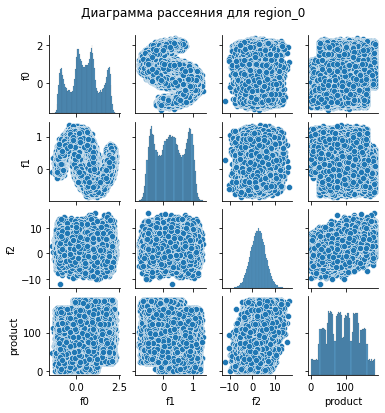

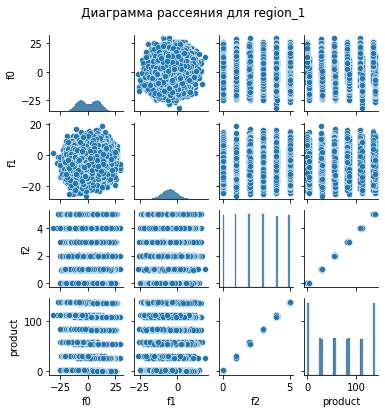

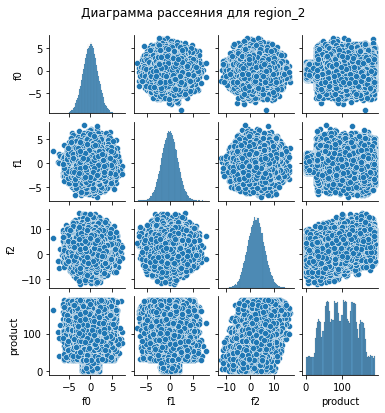

In [7]:
for region in tables:
    g = sns.pairplot(region, height=1.35)
    g.fig.suptitle(f'Scatterplot for {region.name}', y=1.05)

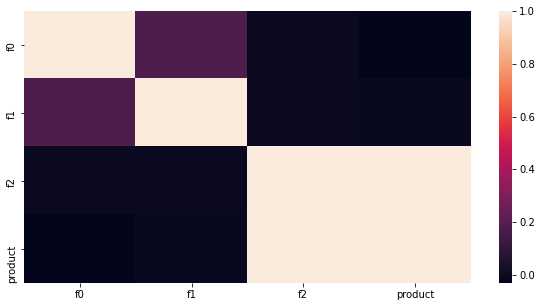

In [8]:
#correlation matrix for the 1st region
plt.figure(figsize=(10,5))
sns.heatmap(region_1.corr());

The graph shows a high correlation between the reserve volume and f2 feature in the first region.

### Conclusions

* **To minimize overfitting of linear regression models, the columns with unique wells' ids were removed;**
* **It is worth mentioning that there were duplicate values for the wells' ids. This fact may be related to repeated sampling. It should also be noted that there are only 12 unique values of reserves for wells in region number 1, while there are no completely identical rows. This should be reported to the customer and the models should be corrected in the future;**
* **At the next stage, we will train linear regression models, but firstly, divide the dataset into training and validation sets with obersvations scaling.**

## Model fitting and testing

In [9]:
#linear regression model function, which includes dataset splitting, scaling, pipeline and metrics 
def regr_model(dataset):
    features = dataset.drop('product', axis = 1)
    target = dataset['product']
    #splitting
    features_train, features_valid, target_train, target_valid = train_test_split(features, 
                                                                            target, 
                                                                            test_size = 0.25, 
                                                                            random_state = 42)
    
    #scaling observations for linear regression
    scaler = make_column_transformer(
        (StandardScaler(),
        make_column_selector(dtype_include=np.number)
        )
    )
    
    #pipeline with scaling
    regr_pipe = Pipeline(steps=[('preprocessor', scaler), 
                               ('regr', LinearRegression(n_jobs=-1))])
    
    #linear regression model
    regr_pipe.fit(features_train,target_train) 
    predicted_valid = regr_pipe.predict(features_valid) #predicted values
    predicted_mean_barrels = predicted_valid.mean() #average predicted volume of oil 
    target_mean = target_valid.mean() #average volume of oil for validation set
    rmse = (mean_squared_error(target_valid, predicted_valid) ** 0.5)
    r2 = r2_score(target_valid, predicted_valid)
    
    #info dict with the model, predicted and actual values, and metrics 
    info = {'model': regr_pipe,
            'predicted_valid': predicted_valid,
            'target_valid': target_valid.reset_index(drop = True), 
            'predicted_mean_barrels': predicted_mean_barrels,
            'target_mean_barrels': target_mean,
            'rmse': rmse,
            'r2': r2             
            }
    
    return info

### Model fitting for region 0

In [10]:
model_reg_0 = regr_model(region_0)

In [11]:
print('Average predicted oil volume, thousands of barrels:', round(model_reg_0['predicted_mean_barrels'], 2))
print('Average actual oil volume, thousands of barrels:', round(model_reg_0['target_mean_barrels'], 2))
print('RMSE value, thousands of barrels:', round(model_reg_0['rmse'], 2))
print('R2 coefficient:', round(model_reg_0['r2'], 2))

Средний запас предсказанного сырья, тыс. баррелей: 92.4
Средний фактический запас сырья, тыс. баррелей: 92.33
Значение среднеквадратичной ошибки RMSE, тыс. баррелей: 37.76
Значение коэффициента детерминации r2: 0.27


### Model fitting for region 1

In [12]:
model_reg_1 = regr_model(region_1)

In [13]:
print('Average predicted oil volume, thousands of barrels:', round(model_reg_1['predicted_mean_barrels'], 2))
print('Average actual oil volume, thousands of barrels:', round(model_reg_1['target_mean_barrels'], 2))
print('RMSE value, thousands of barrels:', round(model_reg_1['rmse'], 2))
print('R2 coefficient:', round(model_reg_1['r2'], 2))

Средний запас предсказанного сырья, тыс. баррелей: 68.71
Средний фактический запас сырья, тыс. баррелей: 68.73
Значение среднеквадратичной ошибки RMSE, тыс. баррелей: 0.89
Значение коэффициента детерминации r2: 1.0


### Model fitting for region 2

In [14]:
model_reg_2 = regr_model(region_2)

In [15]:
print('Average predicted oil volume, thousands of barrels:', round(model_reg_2['predicted_mean_barrels'], 2))
print('Average actual oil volume, thousands of barrels:', round(model_reg_2['target_mean_barrels'], 2))
print('RMSE value, thousands of barrels:', round(model_reg_2['rmse'], 2))
print('R2 coefficient:', round(model_reg_2['r2'], 2))

Средний запас предсказанного сырья, тыс. баррелей: 94.77
Средний фактический запас сырья, тыс. баррелей: 95.15
Значение среднеквадратичной ошибки RMSE, тыс. баррелей: 40.15
Значение коэффициента детерминации r2: 0.2


### Pivoting quality metrics

In [16]:
#metrics list
models_pred_bar = [model_reg_0['predicted_mean_barrels'],
                   model_reg_1['predicted_mean_barrels'], 
                   model_reg_2['predicted_mean_barrels']]

models_act_bar = [model_reg_0['target_mean_barrels'], 
                  model_reg_1['target_mean_barrels'], 
                  model_reg_2['target_mean_barrels']]

models_rmse = [model_reg_0['rmse'], model_reg_1['rmse'], model_reg_2['rmse']]

models_r2 = [model_reg_0['r2'], model_reg_1['r2'], model_reg_2['r2']]

#metrics dataframe
scorings = pd.DataFrame(
    data=[models_pred_bar, models_act_bar, models_rmse, models_r2], 
    index=['Average predicted oil volume',
           'Average actual oil volume',
           'RMSE', 
           'R2'], 
    columns=['region 0','region 1','region 2'])

display(scorings)

,region 0,region 1,region 2
Средний предсказанный объем сырья,92.398800,68.712878,94.771024
Средний фактический объем сырья,92.325956,68.725381,95.150999
Среднеквадратичная ошибка,37.756600,0.890280,40.145872
Коэффициент детерминации,0.272829,0.999625,0.196347


### Conclusions

* **The linear regression model demonstrates the best forecasting quality for region №1. There are a high coefficient of determination and a small root-mean-square error;**
* **The predicted average volumes are almost identical to the average actual volumes.**


## Evaluating profits

Based on choosing 200 potentially profitable wells, we'll estimate enough oil volume for the oil well break-even development.

In [17]:
TOP_NUMBER = 200 #number of profitable oil wells
INVESTMENTS = 10*(10**9) #investment volume in a region, 10 bln rubles
BARREL_PRICE = 450000 #доход за тыс. баррелей

In [18]:
lossless_barrels = round(INVESTMENTS/TOP_NUMBER/BARREL_PRICE, 2)
print('The oil volume enough for break-even development, thousands of barrels:', lossless_barrels)

Объём сырья для безубыточной разработки новой скважины, тыс. баррелей: 111.11


### Conclusions

* **The minimum required oil volume for break-even production in the well should be 111.11 thousand barrels.**

## Calculating profits and risks

In [19]:
#profit calcaulating function for top 200 wells based on volumes
def profit(target_valid, predicted_valid):
    probabilities = pd.Series(predicted_valid).sort_values(ascending=False)
    chosen = target_valid[probabilities.index][:top_number]
    return (chosen.sum() * barrel_price - investments)

### Region 0 profit

In [20]:
print('Top 200 wells profit for region 0, bln rubles:', 
      round(profit(model_reg_0['target_valid'], model_reg_0['predicted_valid']) / 10**9, 2))

Прибыль топ 200 скважин для региона 0, млрд руб.: 3.36


Using a bootstrap, we'll estimate the average profit for each region, the confidence interval, and the risks.

In [21]:
#evaluating confidence interval function, model as an argument
def conf_interval(model):
    state = np.random.RandomState(42)
    profits = []
    #bootstrap    
    for i in range(1000):
        target_subsample = model['target_valid'].sample(n = 500, replace=True, random_state=state) #sampling actual values
        probs_subsample = pd.Series(model['predicted_valid'])[target_subsample.index] #sampling predictions with the same index
        profits.append(profit(target_subsample, probs_subsample)) #calculating profit for the sample
    
    profits = pd.Series(profits)
    lower = round(profits.quantile(0.025) / 10**9, 3) #confidence interval lower bounds, bln
    upper = round(profits.quantile(0.975) / 10**9, 3) #confidence interval upper bounds, bln
    
    print('Average profit, bln rubles:', round(profits.mean() / 10**9, 3))
    print('Loss probability, %:', round((profits < 0).mean() * 100, 3)) #доля значений, составляющих меньше 0
    print('Confidence limits, bln rubles:', lower, upper)

In [22]:
conf_interval(model_reg_0)

Средняя прибыль, млрд руб.: 0.428
Вероятность убытков, %: 5.5
Границы доверительного интервала, млрд руб.: -0.097 0.954


### Region 1 profit

In [23]:
print('Top 200 wells profit for region 0, bln rubles:', 
      round(profit(model_reg_1['target_valid'], model_reg_1['predicted_valid']) / 10**9, 2))

Прибыль топ 200 скважин для региона 1, млрд руб.: 2.42


In [24]:
conf_interval(model_reg_1)

Средняя прибыль, млрд руб.: 0.511
Вероятность убытков, %: 0.9
Границы доверительного интервала, млрд руб.: 0.099 0.941


### Region 2 profit

In [25]:
print('Top 200 wells profit for region 0, bln rubles:', 
      round(profit(model_reg_2['target_valid'], model_reg_2['predicted_valid']) / 10**9, 2))

Прибыль топ 200 скважин для региона 2, млрд руб.: 2.6


In [26]:
conf_interval(model_reg_2)

Средняя прибыль, млрд руб.: 0.403
Вероятность убытков, %: 7.4
Границы доверительного интервала, млрд руб.: -0.137 0.93


## Summary

* **By the developed logistic regression models and investments risk assessment in the development of new oil wells, the most preferable region is region #1. Despite the high profitability of the 200 best wells for regions 0 and 2 (3.36 and 2.6 billion rubles), region 1 is characterized by the least risk (the probability of losses is 0.9%). This is evidenced by the boundaries of the confidence interval (0.099-0.941 billion rubles), which do not go into negative values, and the average profitability of wells (0.511 billion rubles).**
* **However, the model may require further adjustment because there are duplicates for oil wells' ids in the observations and there are only 12 unique values for oil wells in region number 1, where there are no completely identical rows.**